In [7]:
!unzip PetImages.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/PetImages/Cat/7419.jpg  
  inflating: /content/PetImages/Cat/742.jpg  
  inflating: /content/PetImages/Cat/7420.jpg  
  inflating: /content/PetImages/Cat/7421.jpg  
  inflating: /content/PetImages/Cat/7422.jpg  
  inflating: /content/PetImages/Cat/7423.jpg  
  inflating: /content/PetImages/Cat/7424.jpg  
  inflating: /content/PetImages/Cat/7425.jpg  
  inflating: /content/PetImages/Cat/7426.jpg  
  inflating: /content/PetImages/Cat/7427.jpg  
  inflating: /content/PetImages/Cat/7428.jpg  
  inflating: /content/PetImages/Cat/7429.jpg  
  inflating: /content/PetImages/Cat/743.jpg  
  inflating: /content/PetImages/Cat/7430.jpg  
  inflating: /content/PetImages/Cat/7431.jpg  
  inflating: /content/PetImages/Cat/7432.jpg  
  inflating: /content/PetImages/Cat/7433.jpg  
  inflating: /content/PetImages/Cat/7434.jpg  
  inflating: /content/PetImages/Cat/7435.jpg  
  inflating: /content/PetImages/Cat/7436.jpg  
  inflating

In [8]:
import os, shutil, random

def split_data(source_dir, train_dir, val_dir, split=0.8):
    files = [f for f in os.listdir(source_dir) if f.endswith(".jpg")]
    random.shuffle(files)
    split_size = int(len(files) * split)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for f in files[:split_size]:
        shutil.copy(os.path.join(source_dir, f), train_dir)

    for f in files[split_size:]:
        shutil.copy(os.path.join(source_dir, f), val_dir)

# Split
split_data("/content/PetImages/Cat", "/content/dataset/train/cats", "/content/dataset/validation/cats")
split_data("/content/PetImages/Dog", "/content/dataset/train/dogs", "/content/dataset/validation/dogs")

In [11]:
from PIL import Image
import os

def remove_corrupt_images(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()  # check image
            except:
                print("Removing:", file_path)
                os.remove(file_path)

# Run for dataset
remove_corrupt_images("/content/dataset")

Removing: /content/dataset/validation/dogs/11702.jpg
Removing: /content/dataset/train/cats/666.jpg


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_path = "/content/dataset/train"
val_path = "/content/dataset/validation"

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_data, epochs=10, validation_data=val_data)

Found 11704 images belonging to 2 classes.
Found 2926 images belonging to 2 classes.
Epoch 1/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.8542 - loss: 0.4190 - val_accuracy: 0.8544 - val_loss: 0.3849
Epoch 2/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.8543 - loss: 0.3943 - val_accuracy: 0.8575 - val_loss: 0.3613
Epoch 3/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.8598 - loss: 0.3685 - val_accuracy: 0.8671 - val_loss: 0.3288
Epoch 4/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - accuracy: 0.8675 - loss: 0.3470 - val_accuracy: 0.8763 - val_loss: 0.3083
Epoch 5/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.8702 - loss: 0.3356 - val_accuracy: 0.8824 - val_loss: 0.3092
Epoch 6/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.8758 - loss: 0.3225 - val_accuracy: 0.8647 - val_loss: 0.3287
Epoch 7/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.8775 - loss: 0.3121 - val_accuracy: 0.8821 - val_loss: 0.3074
Epoch 8/10
3

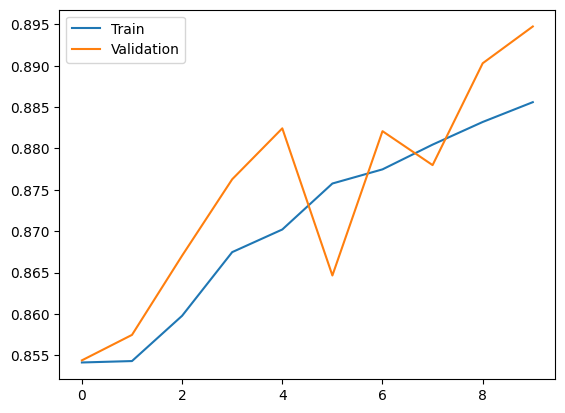

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/test.jpg"

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Prediction: Dog 🐶


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/test1.jpg"

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: Cat 🐱
